In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / 'date').is_dir() and (p / 'images').is_dir()
)
DATA_DIR = PROJECT_ROOT / 'date'
IMAGES_DIR = PROJECT_ROOT / 'images'
sns.set_theme(style="whitegrid",font_scale = 1.2)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
#数据读取
df = pd.read_parquet(DATA_DIR / 'user_behavior_cleaned_dataset.parquet')
print(df.head(5))

     user_id  item_id  category_id behavior_type           timestamp  \
494   114726  2014874      1901483            pv 2017-11-24 16:00:00   
495   108891  4295341      3855599            pv 2017-11-24 16:00:01   
496   127538  1849003      2072473            pv 2017-11-24 16:00:01   
497   104088  4539468      3702593            pv 2017-11-24 16:00:02   
498   111942  1005979      2735466            pv 2017-11-24 16:00:02   

          date  
494 2017-11-25  
495 2017-11-25  
496 2017-11-25  
497 2017-11-25  
498 2017-11-25  


In [3]:
result_pv = df[df['behavior_type'] == 'pv']
result_fav = df[df['behavior_type'] == 'fav']
result_cart = df[df['behavior_type'] == 'cart']
result_buy = df[df['behavior_type'] == 'buy']

pv_users = set(result_pv['user_id'])
first_pv_time = result_pv.groupby('user_id')['timestamp'].min().rename('first_pv_time')

intent_result = pd.concat([result_cart, result_fav], ignore_index=True).merge(
    first_pv_time,
    on='user_id',
    how='inner'
)
intent_result = intent_result[intent_result['timestamp'] >= intent_result['first_pv_time']]

buy_result = result_buy.merge(first_pv_time, on='user_id', how='inner')
buy_result = buy_result[buy_result['timestamp'] >= buy_result['first_pv_time']]

count_pv = len(pv_users)
count_intent = intent_result['user_id'].nunique()
count_buy = buy_result['user_id'].nunique()

print(f"浏览用户{count_pv}，浏览后收藏或加购{count_intent}人，浏览后购买{count_buy}人；"
      f"浏览到意向转化率{count_intent/count_pv:.2%}，浏览到支付转化率{count_buy/count_pv:.2%}")

浏览用户10169，浏览后收藏或加购8790人，浏览后购买6882人；浏览到意向转化率86.44%，浏览到支付转化率67.68%


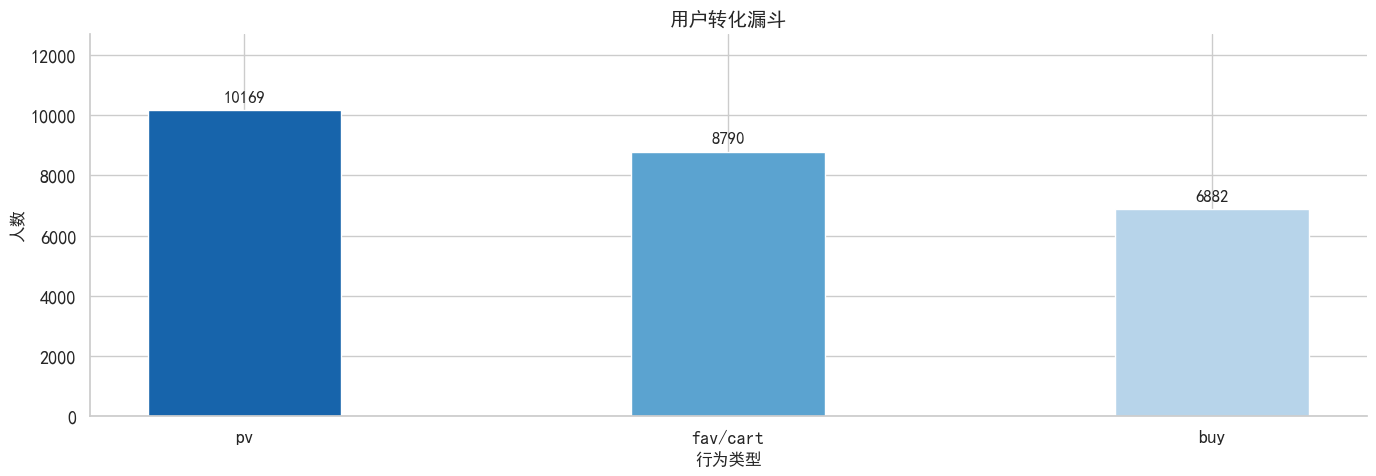

In [4]:
df_ratio = pd.DataFrame({
      '行为':['pv','fav/cart','buy'],
      '人数':[count_pv,count_intent,count_buy]
})
fig,axes = plt.subplots(figsize=(14,5))
colors = plt.cm.Blues(np.linspace(0.8,0.3,len(df_ratio)))
axes.bar(df_ratio['行为'],df_ratio['人数'],color = colors,width=0.4)
for i,(behavior,count) in enumerate(zip(df_ratio['行为'],df_ratio['人数'])):
    axes.text(i,count + max(df_ratio['人数']) * 0.02,
              f'{count:.0f}',
              ha = 'center',
              va = 'bottom',
              fontsize = 12,
              fontweight = 'bold',
              )
axes.set_title('用户转化漏斗',fontsize=14)
axes.set_xlabel('行为类型',fontsize=12)
axes.set_ylabel('人数',fontsize=12)
axes.set_ylim([0,max(df_ratio['人数'])*1.25])

sns.despine()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'traffic_funnel_analysis.png',dpi=300)